In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [2]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_V2.csv')

In [3]:
X = df.drop('price_per_m2', axis=1)
y = df['price_per_m2']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
def gap_scoring(estimator, X, y):
    """Custom scoring function that minimizes the gap between train and test R²"""
    y_pred_train = estimator.predict(X)
    train_r2 = r2_score(y, y_pred_train)
    
    # Create a validation split
    X_train_val, X_val, y_train_val, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Fit on training portion and predict on validation
    estimator.fit(X_train_val, y_train_val)
    y_pred_val = estimator.predict(X_val)
    val_r2 = r2_score(y_val, y_pred_val)
    
    # Calculate the gap (we want to minimize this)
    gap = abs(train_r2 - val_r2)
    
    # Return a score that prioritizes small gap and good validation R²
    # Weighted combination: 70% validation R²,d 30% gap minimization
    return 0.999 * val_r2 - 0.001 * gap

In [6]:
param_grid = {
    'n_neighbors': [50, 60, 70, 80, 90, 100],
    'leaf_size': [30,40, 50, 60,],
    'p': [1],
}

In [7]:
knn = KNeighborsRegressor(algorithm='auto', weights='uniform')

In [8]:
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=gap_scoring,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'leaf_size': [30, 40, 50, 60],
                         'n_neighbors': [50, 60, 70, 80, 90, 100], 'p': [1]},
             scoring=<function gap_scoring at 0x0000027A3A179C60>, verbose=1)

In [9]:
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

In [10]:
best_params

{'leaf_size': 30, 'n_neighbors': 50, 'p': 1}

In [11]:
# print("Model trained with default parameters:")
# print(f"Number of neighbors (k): {knn.n_neighbors}")
# print(f"Weight function: {knn.weights}")
# print(f"Distance metric: {knn.metric}")

In [12]:
y_pred = best_estimator.predict(X_test)
y_pred_train = best_estimator.predict(X_train)


In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)
gap = r2_train - r2

In [14]:
print("Test set performance:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"R² Train Score: {r2_train:.4f}")
print(f"Gap: {gap:.4f}")

Test set performance:
MSE: 388930.65
RMSE: 623.64
R² Score: 0.8704
R² Train Score: 0.8826
Gap: 0.0122


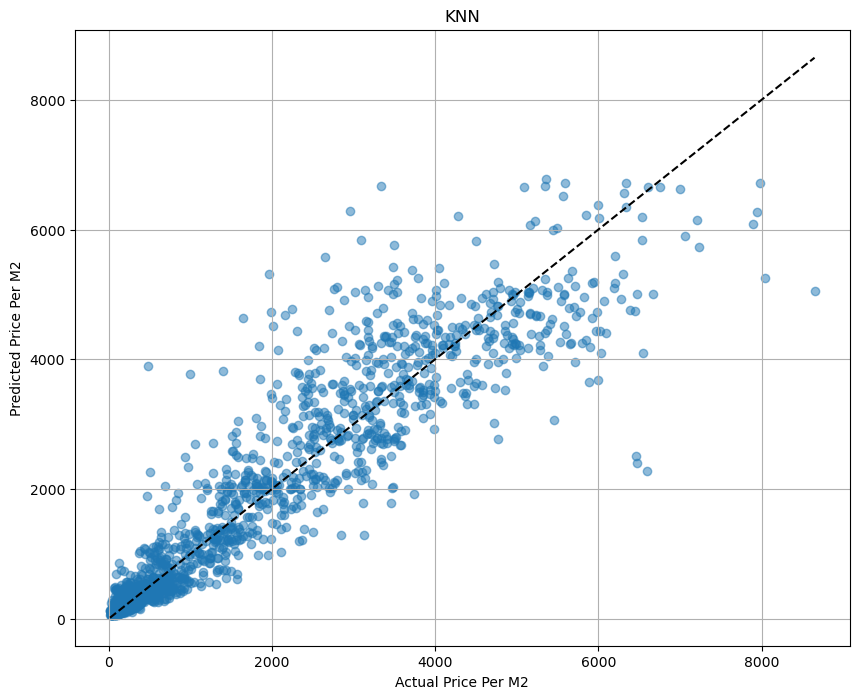

In [15]:
def plot_actual_vs_predicted(y_true, y_pred):
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'k--')
    plt.xlabel('Actual Price Per M2')
    plt.ylabel('Predicted Price Per M2')
    plt.title('KNN')
    plt.grid(True)
    plt.savefig("rf_actual_vs_predicted.png")
    plt.show()

plot_actual_vs_predicted(y_test, y_pred)

In [17]:
import joblib
joblib.dump(best_estimator, "../../../models/knn/knn_model_v1.joblib")

['../../../models/knn/knn_model_v1.joblib']